# 07 — SOH Target Reframe + Stress Markers

nb06 showed LSTM ties RF on 11/13 folds but two outliers (RW1, R²=−6.95; RW9, R²=+0.48) blow up the aggregate.
Both failures share the same root: the **CV-taper curve encodes absolute charge accepted (Ct Ahr)**, but we force
the model to output the ratio `Ct/C0` whose denominator `C0` (per-battery baseline capacity) is hidden.
RW1 has a 2.00 Ahr nominal capacity vs 2.10–2.14 Ahr for the other RW batteries — a constant ~−0.124 level shift.

Two hypotheses to test:

| Tail | Hypothesis | Experiment |
|------|-----------|------------|
| Missing variable | Curve → Ct is stationary; curve → Ct/C0 is not | **E1**: predict absolute Ct (Ahr) |
| Lost stress | 128-pt resample + per-sample z-score kill duration & magnitude | **E2**: add causal stress markers |

**B0** reproduces nb06 as a sanity-check baseline. All arms run RF + LSTM with per-fold scatter plots.

## 1. Imports & setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr
from tqdm.auto import tqdm

ROOT      = Path("..") if Path("../src").exists() else Path(".")
PROCESSED = ROOT / "data" / "processed"
RESULTS   = ROOT / "results"
sys.path.insert(0, str(ROOT / "src"))

from curve_models import LSTMRegPooled, per_sample_scale, jitter
from sequence    import train_model, predict_model

device = torch.device(
    "mps"  if torch.backends.mps.is_available()  else
    "cuda" if torch.cuda.is_available()           else "cpu"
)
torch.manual_seed(42)
np.random.seed(42)
print(f"device: {device}")

device: mps


## 2. Load tensor dataset

In [2]:
data = np.load(PROCESSED / "charge_curves.npz", allow_pickle=True)

X          = data["X"].astype(np.float32)         # (n, 128, 3)  raw, unscaled [V, |I|, T]
soh        = data["soh"].astype(np.float32)        # capacity_retention = Ct / C0
cap_ahr    = data["cap_ahr"].astype(np.float32)    # absolute Ct (Ahr) — E1/E2 target
battery_id = data["battery_id"]
cycle_idx  = data["cycle_index"].astype(np.int32)
scalars    = data["scalars"].astype(np.float32)    # [r_proxy, voltage_mean, temp_mean, temp_max, duration_s]

N_PTS     = X.shape[1]   # 128
C         = X.shape[2]   # 3
all_bids  = sorted(np.unique(battery_id))
CTRL_BIDS = ["B0005", "B0006", "B0007", "B0018"]
mask_all  = np.ones((len(X), N_PTS), dtype=bool)   # no padding — fixed-length curves

print(f"X: {X.shape}  soh: {soh.shape}")
print(f"Batteries ({len(all_bids)}): {all_bids}")
print(f"soh    range: [{soh.min():.3f}, {soh.max():.3f}]")
print(f"cap_ahr range: [{cap_ahr.min():.3f}, {cap_ahr.max():.3f}] Ahr")

X: (788, 128, 3)  soh: (788,)
Batteries (13): ['B0005', 'B0006', 'B0007', 'B0018', 'RW1', 'RW13', 'RW14', 'RW15', 'RW16', 'RW17', 'RW19', 'RW20', 'RW9']
soh    range: [0.357, 1.003]
cap_ahr range: [0.749, 2.137] Ahr


## 3. Derived quantities

### C0_field
`soh = cap_ahr / C0`  →  `C0 = cap_ahr / soh` (constant per battery).
Used to convert Ct predictions back to SOH space for evaluation.

### Causal stress markers
- `cum_ah_lifetime`: lifetime Ah accumulated **before** the current cycle (shifted cumsum; 0 for first cycle).
- `load_std`: running std of per-cycle average discharge current (A) over all **previous** cycles.
  Near-zero for controlled (constant 2 A), high for RW (variable random load) — the key cohort separator.

**Leakage guard:** `cap_ahr ≡ avg_current × duration`, so using the *current* cycle's discharge `avg_current`
and `duration_s` together would reconstruct the label. All discharge-derived markers are strictly causal
(lagged by 1 cycle).

### Curve-derived magnitude markers
Computed from **raw (unscaled) X** to restore the amplitude that `per_sample_scale` removes.
These are charge-side (input), not leaky.

In [3]:
# ── C0_field (per-battery baseline capacity) ─────────────────────────────────
c0_by_bid = {}
for bid in all_bids:
    m = battery_id == bid
    # soh clips to 0.001 to avoid divide-by-zero on rare zero-soh entries
    c0_by_bid[bid] = float(np.median(cap_ahr[m] / soh[m].clip(0.001)))
C0_field = np.array([c0_by_bid[b] for b in battery_id], dtype=np.float32)

print("C0_field per battery (Ahr):")
for bid in all_bids:
    print(f"  {bid}: {c0_by_bid[bid]:.4f}")

# Sanity: C0 should be ~constant within each battery (std < 1% of mean)
for bid in all_bids:
    m = battery_id == bid
    c0_arr = cap_ahr[m] / soh[m].clip(0.001)
    cv = c0_arr.std() / c0_arr.mean()
    assert cv < 0.05, f"{bid}: C0 CoV={cv:.3f} — unexpectedly high"
print("C0_field sanity check passed.")

C0_field per battery (Ahr):
  B0005: 1.8622
  B0006: 2.0467
  B0007: 1.9190
  B0018: 1.8684
  RW1: 2.0003
  RW13: 2.1290
  RW14: 2.1154
  RW15: 2.1191
  RW16: 2.1136
  RW17: 2.1313
  RW19: 2.1320
  RW20: 2.1292
  RW9: 2.0977
C0_field sanity check passed.


In [4]:
# ── Causal stress markers (per battery, sorted by cycle_index) ────────────────
cum_ah_lt  = np.zeros(len(X), dtype=np.float32)
load_std_r = np.zeros(len(X), dtype=np.float32)

for bid in all_bids:
    orig_idx_all  = np.where(battery_id == bid)[0]
    sort_order    = np.argsort(cycle_idx[orig_idx_all])
    orig_idx      = orig_idx_all[sort_order]          # sorted by cycle_index

    ca   = cap_ahr[orig_idx]
    dur  = scalars[orig_idx, 4].clip(1.0)             # duration_s (5th scalar)
    avg_I = ca * 3600.0 / dur                          # per-cycle average discharge current (A)

    # Lifetime cumulative Ah, shifted by 1 so first cycle = 0
    cum_ah_lt[orig_idx] = np.concatenate([[0.0], np.cumsum(ca)[:-1]])

    # Running std of avg_I over strictly-previous cycles
    lstd = np.zeros(len(orig_idx), dtype=np.float32)
    for t in range(2, len(avg_I)):               # need ≥2 points for a std
        lstd[t] = float(avg_I[:t].std())
    load_std_r[orig_idx] = lstd

# Sanity: first cycle of each battery should have cum_ah = 0
for bid in all_bids:
    m   = np.where(battery_id == bid)[0]
    fi  = m[np.argmin(cycle_idx[m])]
    assert cum_ah_lt[fi] == 0.0, f"{bid}: first cum_ah != 0"
print(f"cum_ah_lifetime range: [{cum_ah_lt.min():.2f}, {cum_ah_lt.max():.2f}] Ahr")
print(f"load_std range:        [{load_std_r.min():.4f}, {load_std_r.max():.4f}] A")
print("Causal markers sanity check passed.")

cum_ah_lifetime range: [0.00, 276.51] Ahr
load_std range:        [0.0000, 0.1439] A
Causal markers sanity check passed.


In [5]:
# ── Curve-derived magnitude markers (raw X) ───────────────────────────────────
V_min_r  = X[:, :, 0].min(axis=1)
V_max_r  = X[:, :, 0].max(axis=1)
I_mean_r = X[:, :, 1].mean(axis=1)
I_std_r  = X[:, :, 1].std(axis=1)

# Full E2 stress vector: (n, 6)
stress_markers = np.stack(
    [cum_ah_lt, load_std_r, V_min_r, V_max_r, I_mean_r, I_std_r], axis=1
).astype(np.float32)
STRESS_COLS = ["cum_ah_lifetime", "load_std", "V_min", "V_max", "I_mean", "I_std"]

print(f"stress_markers: {stress_markers.shape}")
for col, vals in zip(STRESS_COLS, stress_markers.T):
    print(f"  {col:<20} mean={vals.mean():.4f}  std={vals.std():.4f}")

# ── 9 charge-curve scalars (same as nb06 RF baseline, computed from raw X) ───
def charge_scalars_fn(X_arr):
    V, I, T = X_arr[:, :, 0], X_arr[:, :, 1], X_arr[:, :, 2]
    L = X_arr.shape[1]
    return np.stack([
        V.mean(axis=1), I.mean(axis=1), I.std(axis=1),
        T.mean(axis=1), T.max(axis=1),
        T[:, -1] - T[:, 0],   # T_rise
        I[:, -1] - I[:, 0],   # I_droop
        V[:, L // 2],          # V_mid
        T.std(axis=1),
    ], axis=1).astype(np.float32)

CHARGE_SC_COLS = ["V_mean","I_mean","I_std","T_mean","T_max","T_rise","I_droop","V_mid","T_std"]
charge_sc = charge_scalars_fn(X)
print(f"charge_sc: {charge_sc.shape}")

stress_markers: (788, 6)
  cum_ah_lifetime      mean=111.8176  std=82.3258
  load_std             mean=0.0393  std=0.0352
  V_min                mean=4.1525  std=0.0083
  V_max                mean=4.2061  std=0.0066
  I_mean               mean=0.3941  std=0.0552
  I_std                mean=0.4503  std=0.0531
charge_sc: (788, 9)


## 4. Shared utilities

In [6]:
import warnings
from scipy.stats import ConstantInputWarning

# ── Curve scaling helpers ─────────────────────────────────────────────────────

def global_scale_curves(X_in, X_va, X_te):
    """Per-channel StandardScaler on inner-train — preserves inter-sample amplitude."""
    n_in, L, nc = X_in.shape
    n_va, n_te  = len(X_va), len(X_te)
    sc = StandardScaler().fit(X_in.reshape(-1, nc))
    return (
        sc.transform(X_in.reshape(-1, nc)).reshape(n_in, L, nc).astype(np.float32),
        sc.transform(X_va.reshape(-1, nc)).reshape(n_va, L, nc).astype(np.float32),
        sc.transform(X_te.reshape(-1, nc)).reshape(n_te, L, nc).astype(np.float32),
    )

# ── Inference without [0,1] clip (for absolute Ct predictions) ───────────────

@torch.no_grad()
def predict_raw(model, X_arr, m_arr, dev, batch_size=512, S=None):
    model.eval()
    preds = []
    Xt = torch.tensor(X_arr, dtype=torch.float32)
    mt = torch.tensor(m_arr,  dtype=torch.bool)
    St = torch.tensor(S, dtype=torch.float32) if S is not None else None
    for i in range(0, len(Xt), batch_size):
        sb = St[i:i+batch_size].to(dev) if St is not None else None
        preds.append(
            model(Xt[i:i+batch_size].to(dev), mt[i:i+batch_size].to(dev), sb)
            .cpu().numpy()
        )
    return np.concatenate(preds)

# ── Metrics ──────────────────────────────────────────────────────────────────

def monotonicity_rate(y_pred):
    if len(y_pred) < 2: return float("nan")
    return float((np.diff(y_pred) <= 0).mean())

def lobo_metrics(y_te, y_pred, cidx_te, train_mean, eol=None):
    mae       = mean_absolute_error(y_te, y_pred)
    naive_mae = mean_absolute_error(y_te, np.full(len(y_te), train_mean))
    order     = np.argsort(cidx_te)
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConstantInputWarning)
        sp = float(spearmanr(y_te, y_pred).statistic)
    fold = {
        "mae":          mae,
        "rmse":         float(np.sqrt(mean_squared_error(y_te, y_pred))),
        "r2":           r2_score(y_te, y_pred),
        "naive_mae":    naive_mae,
        "skill":        float(1 - mae / naive_mae) if naive_mae > 0 else float("nan"),
        "spearman":     sp,
        "monotonicity": monotonicity_rate(y_pred[order]),
        "y_true_arr":   y_te,
        "y_pred_arr":   y_pred,
        "cidx_arr":     cidx_te,
    }
    if eol is not None:
        fold["cap_mae_ahr"] = mean_absolute_error(y_te * eol, y_pred * eol)
    return fold

def aggregate(fold_list):
    out = {}
    for key in ["mae","rmse","r2","naive_mae","skill","spearman","monotonicity","cap_mae_ahr"]:
        vals = [f[key] for f in fold_list if key in f and not (isinstance(f[key], float) and np.isnan(f[key]))]
        if vals:
            out[key]           = float(np.mean(vals))
            out[f"{key}_std"]  = float(np.std(vals))
    out["per_fold"] = fold_list
    return out

# ── Per-fold scatter plot ─────────────────────────────────────────────────────

def per_fold_plot(fold_list, title, save_path=None):
    bids  = sorted(f["battery"] for f in fold_list)
    n     = len(bids)
    ncols = min(4, n); nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5*ncols, 3*nrows))
    axes = np.array(axes).flatten()
    fd = {f["battery"]: f for f in fold_list}
    for i, bid in enumerate(bids):
        ax  = axes[i]
        fld = fd[bid]
        yt  = fld["y_true_arr"]; yp = fld["y_pred_arr"]
        color = "#1f77b4" if bid.startswith("B") else "#ff7f0e"
        ax.scatter(yt, yp, s=12, alpha=0.7, color=color)
        lo = min(yt.min(), yp.min()) - 0.02; hi = max(yt.max(), yp.max()) + 0.02
        ax.plot([lo, hi], [lo, hi], "k--", lw=0.8, alpha=0.5)
        ax.set_title(f"{bid}\nMAE={fld['mae']:.3f}  R²={fld['r2']:.2f}", fontsize=8)
        ax.set_xlabel("True SOH", fontsize=7); ax.set_ylabel("Pred SOH", fontsize=7)
        ax.tick_params(labelsize=6)
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=10, y=1.01)
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()

print("Utilities ready.")

Utilities ready.


In [7]:
# ── LOBO runners ─────────────────────────────────────────────────────────────
#
# run_lobo_rf   — Random Forest on scalar features; O(seconds) per fold.
# run_lobo_lstm — LSTM, sequential folds (no ThreadPoolExecutor).
#
# Threading dropped: MPS serialises all device ops anyway so parallelism gives
# zero GPU speedup, and concurrent torch.Generator(device="mps") calls across
# threads deadlock before the first epoch starts.
#
# Both runners train in `target_arr` space and report metrics in SOH space
# (Ct predictions are converted via C0_field before metric computation).
# ─────────────────────────────────────────────────────────────────────────────

BATCH_SIZE = 32
PATIENCE   = 50
SIGMA_JIT  = 0.005


def _ct_to_soh(y_pred_ct, is_test_mask):
    return (y_pred_ct / C0_field[is_test_mask]).clip(0, 1.1)


def run_lobo_rf(scalar_features, target_arr, label="RF"):
    is_ct = target_arr is not soh
    fold_results = []
    for held_out in tqdm(all_bids, desc=f"LOBO {label}"):
        is_test  = battery_id == held_out
        is_train = ~is_test
        sc = StandardScaler().fit(scalar_features[is_train])
        X_tr = sc.transform(scalar_features[is_train])
        X_te = sc.transform(scalar_features[is_test])
        y_tr = target_arr[is_train]
        y_te_soh = soh[is_test]
        train_soh_mean = soh[is_train].mean()
        rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
        rf.fit(X_tr, y_tr)
        y_pred_raw = rf.predict(X_te)
        y_pred_soh = _ct_to_soh(y_pred_raw, is_test) if is_ct else y_pred_raw.clip(0, 1.0)
        fold = lobo_metrics(y_te_soh, y_pred_soh, cycle_idx[is_test], train_soh_mean,
                            eol=cap_ahr[is_test])
        fold["battery"] = held_out
        fold_results.append(fold)
    return aggregate(fold_results)


def run_lobo_lstm(arch_factory, target_arr, scale_mode, scalar_arr=None, lr=3e-4, label="LSTM"):
    """
    scale_mode : "per_sample" | "global"
    scalar_arr : (n, k) extra scalars for the hybrid head, or None.
    """
    is_ct = target_arr is not soh

    fold_results = []
    for fold_idx, held_out in enumerate(tqdm(all_bids, desc=f"LOBO {label}", unit="fold")):
        # Seed before model init and training so each fold is reproducible
        torch.manual_seed(fold_idx * 31 + 42)
        model = arch_factory().to(device)

        train_bids = [b for b in all_bids if b != held_out]
        avail_ctrl = [b for b in CTRL_BIDS if b in train_bids]
        val_bid    = sorted(avail_ctrl)[-1] if avail_ctrl else sorted(train_bids)[-1]
        inner_bids = [b for b in train_bids if b != val_bid]

        is_inner = np.isin(battery_id, inner_bids)
        is_val   = battery_id == val_bid
        is_test  = battery_id == held_out

        if scale_mode == "per_sample":
            X_in_s = per_sample_scale(X[is_inner])
            X_va_s = per_sample_scale(X[is_val])
            X_te_s = per_sample_scale(X[is_test])
        else:
            X_in_s, X_va_s, X_te_s = global_scale_curves(X[is_inner], X[is_val], X[is_test])

        S_in = S_va = S_te = None
        if scalar_arr is not None:
            sc = StandardScaler().fit(scalar_arr[is_inner])
            S_in = sc.transform(scalar_arr[is_inner]).astype(np.float32)
            S_va = sc.transform(scalar_arr[is_val]).astype(np.float32)
            S_te = sc.transform(scalar_arr[is_test]).astype(np.float32)

        y_in = target_arr[is_inner]
        y_va = target_arr[is_val]
        y_te_soh = soh[is_test]
        train_soh_mean = soh[is_inner | is_val].mean()

        # No explicit rng — torch.manual_seed above seeds the global MPS state,
        # which jitter's torch.zeros_like + .normal_() draws from correctly.
        train_model(
            model, X_in_s, mask_all[is_inner], y_in,
            X_va_s, mask_all[is_val], y_va,
            device, epochs=300, patience=PATIENCE, batch_size=BATCH_SIZE,
            lr=lr, scheduler="cosine", weight_decay=1e-4,
            augment_fn=lambda xb: jitter(xb, sigma=SIGMA_JIT),
            S_tr=S_in, S_val=S_va, progress=False,
        )

        if is_ct:
            y_pred_raw = predict_raw(model, X_te_s, mask_all[is_test], device, S=S_te)
            y_pred_soh = _ct_to_soh(y_pred_raw, is_test)
        else:
            y_pred_soh = predict_model(model, X_te_s, mask_all[is_test], device, S=S_te)

        fold = lobo_metrics(y_te_soh, y_pred_soh, cycle_idx[is_test], train_soh_mean,
                            eol=cap_ahr[is_test])
        fold["battery"] = held_out
        fold_results.append(fold)

    return aggregate(fold_results)


def print_summary_line(label, res):
    r = res
    print(f"{label:<26}  MAE={r['mae']:.4f}±{r['mae_std']:.4f}  "
          f"R²={r['r2']:.3f}±{r['r2_std']:.3f}  "
          f"skill={r['skill']:.3f}  mono={r['monotonicity']:.3f}")


print("LOBO runners ready.")

LOBO runners ready.


---
## B0 — Baseline

Reproduce nb06: RF on 9 charge scalars, LSTM on per-sample-scaled curves, target = `soh`.
Expected: RF MAE ≈ 0.067, LSTM MAE ≈ 0.065 (mean ± std across 13 LOBO folds).

In [8]:
# B0 — RF
res_b0_rf = run_lobo_rf(charge_sc, soh, label="RF B0 (SOH)")
print_summary_line("B0 RF (SOH)", res_b0_rf)

LOBO RF B0 (SOH):   0%|          | 0/13 [00:00<?, ?it/s]

B0 RF (SOH)                 MAE=0.0670±0.0509  R²=0.379±0.713  skill=0.467  mono=0.662


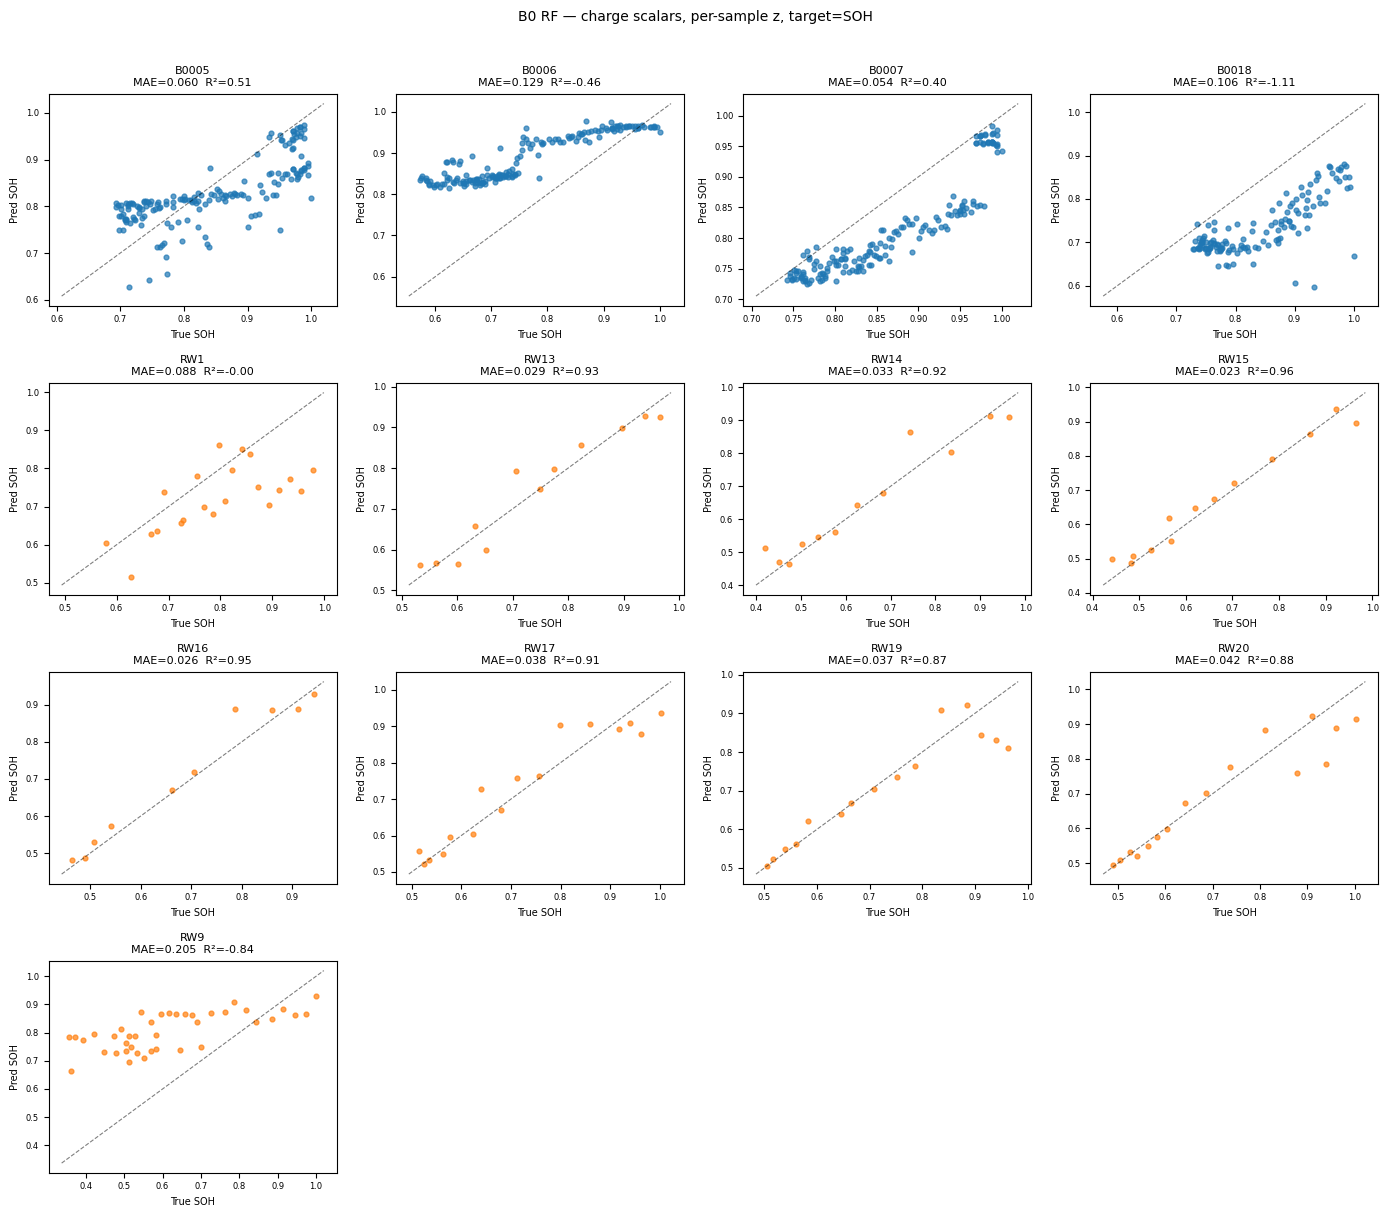

In [9]:
per_fold_plot(
    res_b0_rf["per_fold"],
    "B0 RF — charge scalars, per-sample z, target=SOH",
    save_path=RESULTS / "07_b0_rf_per_fold.png",
)

In [19]:
# B0 — LSTM
arch_b0 = lambda: LSTMRegPooled(C, hidden=64, dropout=0.25)
res_b0_lstm = run_lobo_lstm(arch_b0, soh, "per_sample", label="LSTM B0 (SOH)")
print_summary_line("B0 LSTM (SOH)", res_b0_lstm)

LOBO LSTM B0 (SOH):   0%|          | 0/13 [00:00<?, ?fold/s]

B0 LSTM (SOH)               MAE=0.0610±0.0377  R²=0.443±0.792  skill=0.499  mono=0.716


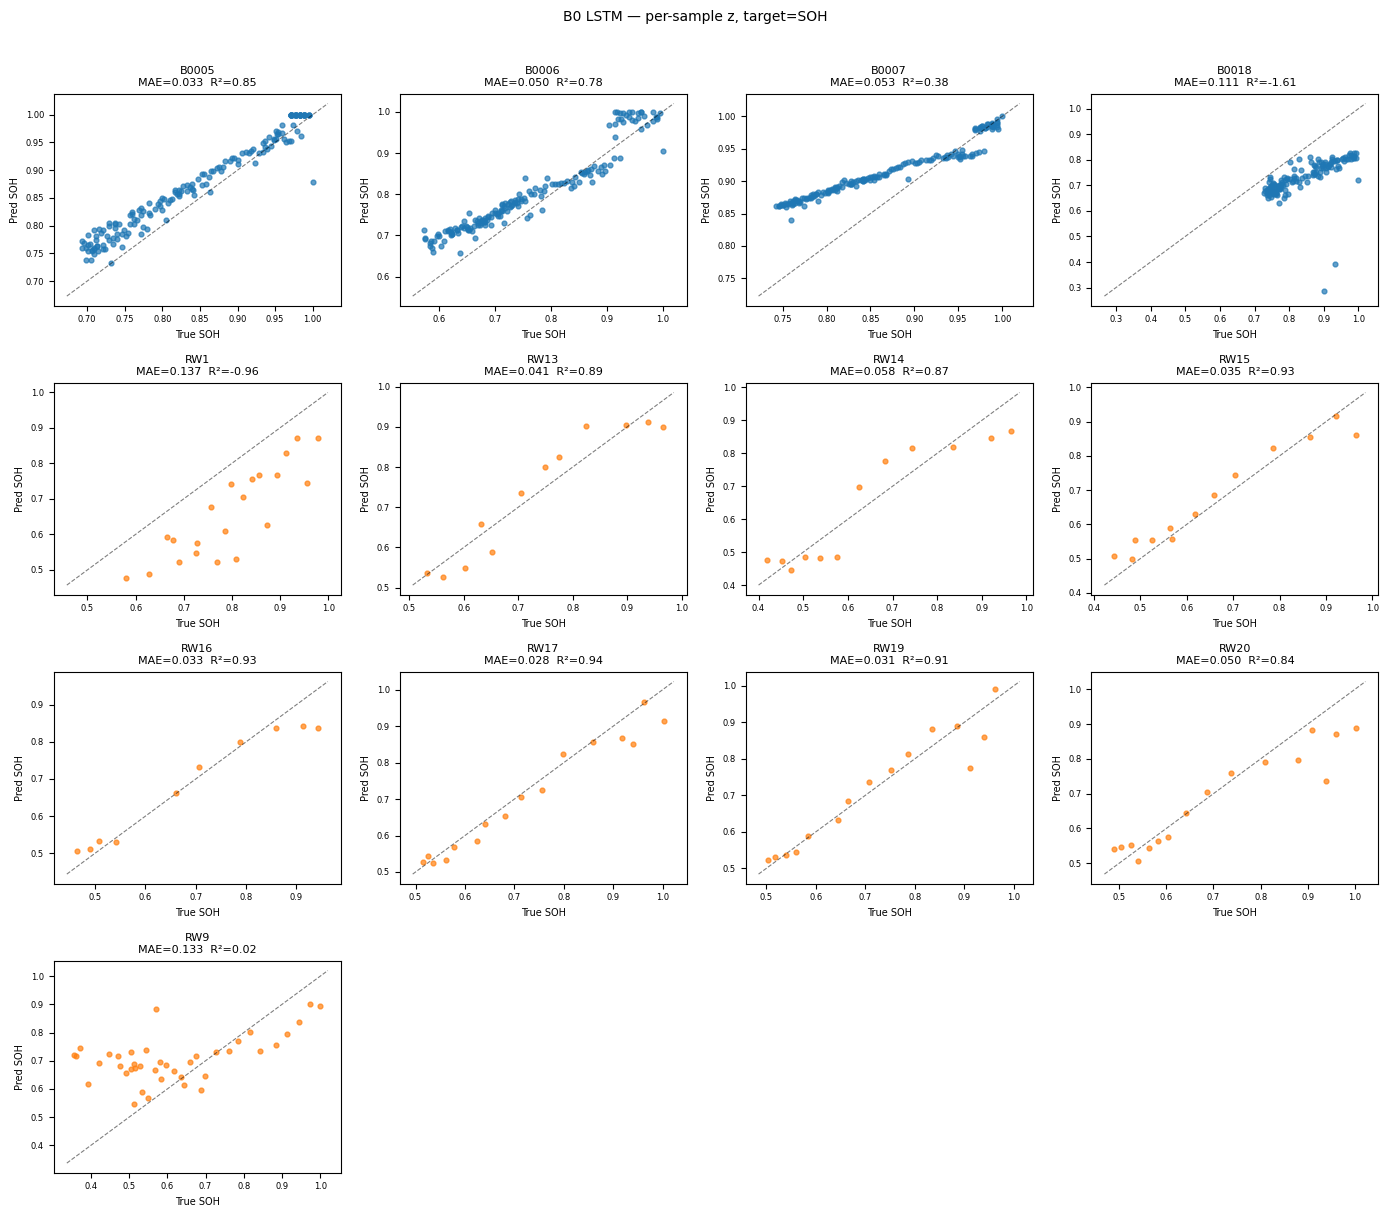

In [23]:
per_fold_plot(
    res_b0_lstm["per_fold"],
    "B0 LSTM — per-sample z, target=SOH",
    save_path=RESULTS / "07_b0_lstm_per_fold.png",
)

---
## E1 — Target Reframe: Predict Absolute Ct (Ahr)

The CV-taper encodes **absolute charge accepted** (Ct Ahr), not the ratio `Ct/C0`.
Training on `cap_ahr` directly removes the hidden-denominator problem: the curve→Ct mapping
is stationary across batteries, while curve→`Ct/C0` is not (C0 varies per battery).

Predictions are converted back to SOH space via `C0_field` (per-battery baseline, known at deploy
from early-life measurements) before metric computation, so all R²/MAE numbers are directly comparable to B0.

We test **two curve scaling modes** for LSTM:
- `per_sample` (current): z-scores each curve → shape-only, kills inter-sample amplitude.
- `global`: per-channel StandardScaler on inner-train → preserves absolute Ct-related amplitude.
  Expected to complement the Ct target since the Ct signal *is* the amplitude.

In [12]:
# E1 — RF (target=cap_ahr, same 9 charge scalars as B0)
res_e1_rf = run_lobo_rf(charge_sc, cap_ahr, label="RF E1 (Ct)")
print_summary_line("E1 RF (Ct)", res_e1_rf)

LOBO RF E1 (Ct):   0%|          | 0/13 [00:00<?, ?it/s]

E1 RF (Ct)                  MAE=0.0622±0.0405  R²=0.471±0.613  skill=0.509  mono=0.655


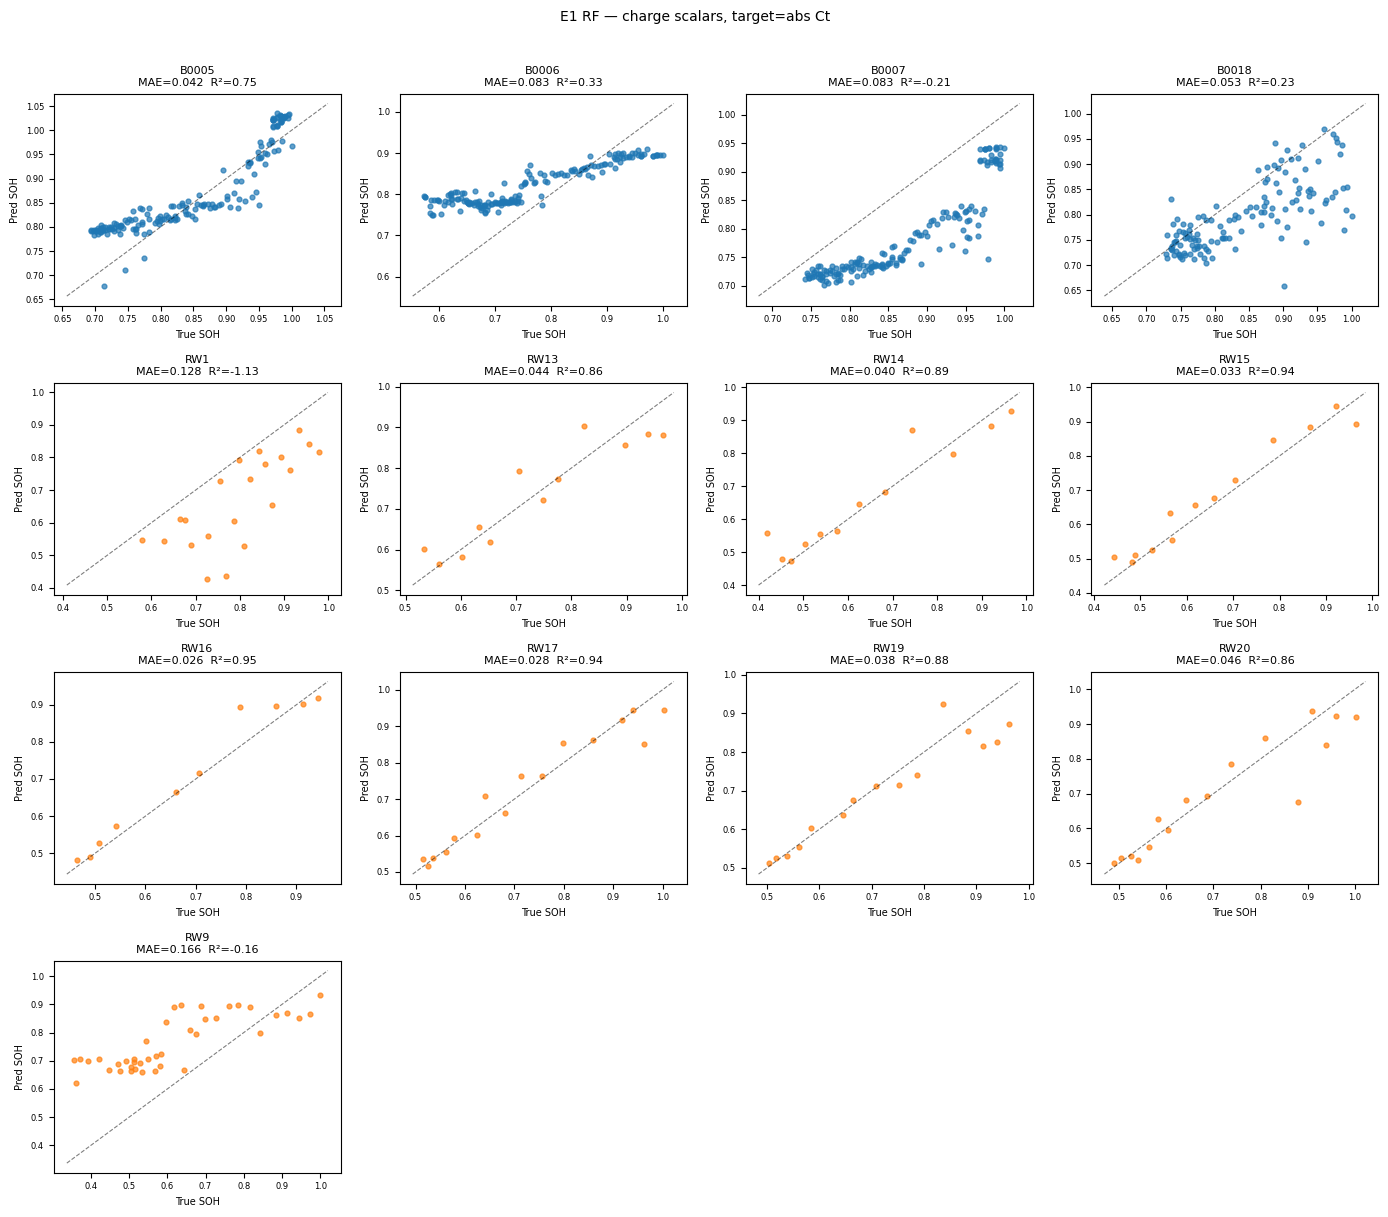

In [13]:
per_fold_plot(
    res_e1_rf["per_fold"],
    "E1 RF — charge scalars, target=abs Ct",
    save_path=RESULTS / "07_e1_rf_per_fold.png",
)

Same mean MAE but -0.01 to std, slightly higher skill. Visually, the curves are scaled better, trends are the same.

In [20]:
# E1a — LSTM, per-sample z-score, target=Ct
arch_e1 = lambda: LSTMRegPooled(C, hidden=64, dropout=0.25)
res_e1_lstm_ps = run_lobo_lstm(arch_e1, cap_ahr, "per_sample", label="LSTM E1 per-sample")
print_summary_line("E1 LSTM per-sample (Ct)", res_e1_lstm_ps)

LOBO LSTM E1 per-sample:   0%|          | 0/13 [00:00<?, ?fold/s]

E1 LSTM per-sample (Ct)     MAE=0.0745±0.0333  R²=0.364±0.689  skill=0.406  mono=0.693


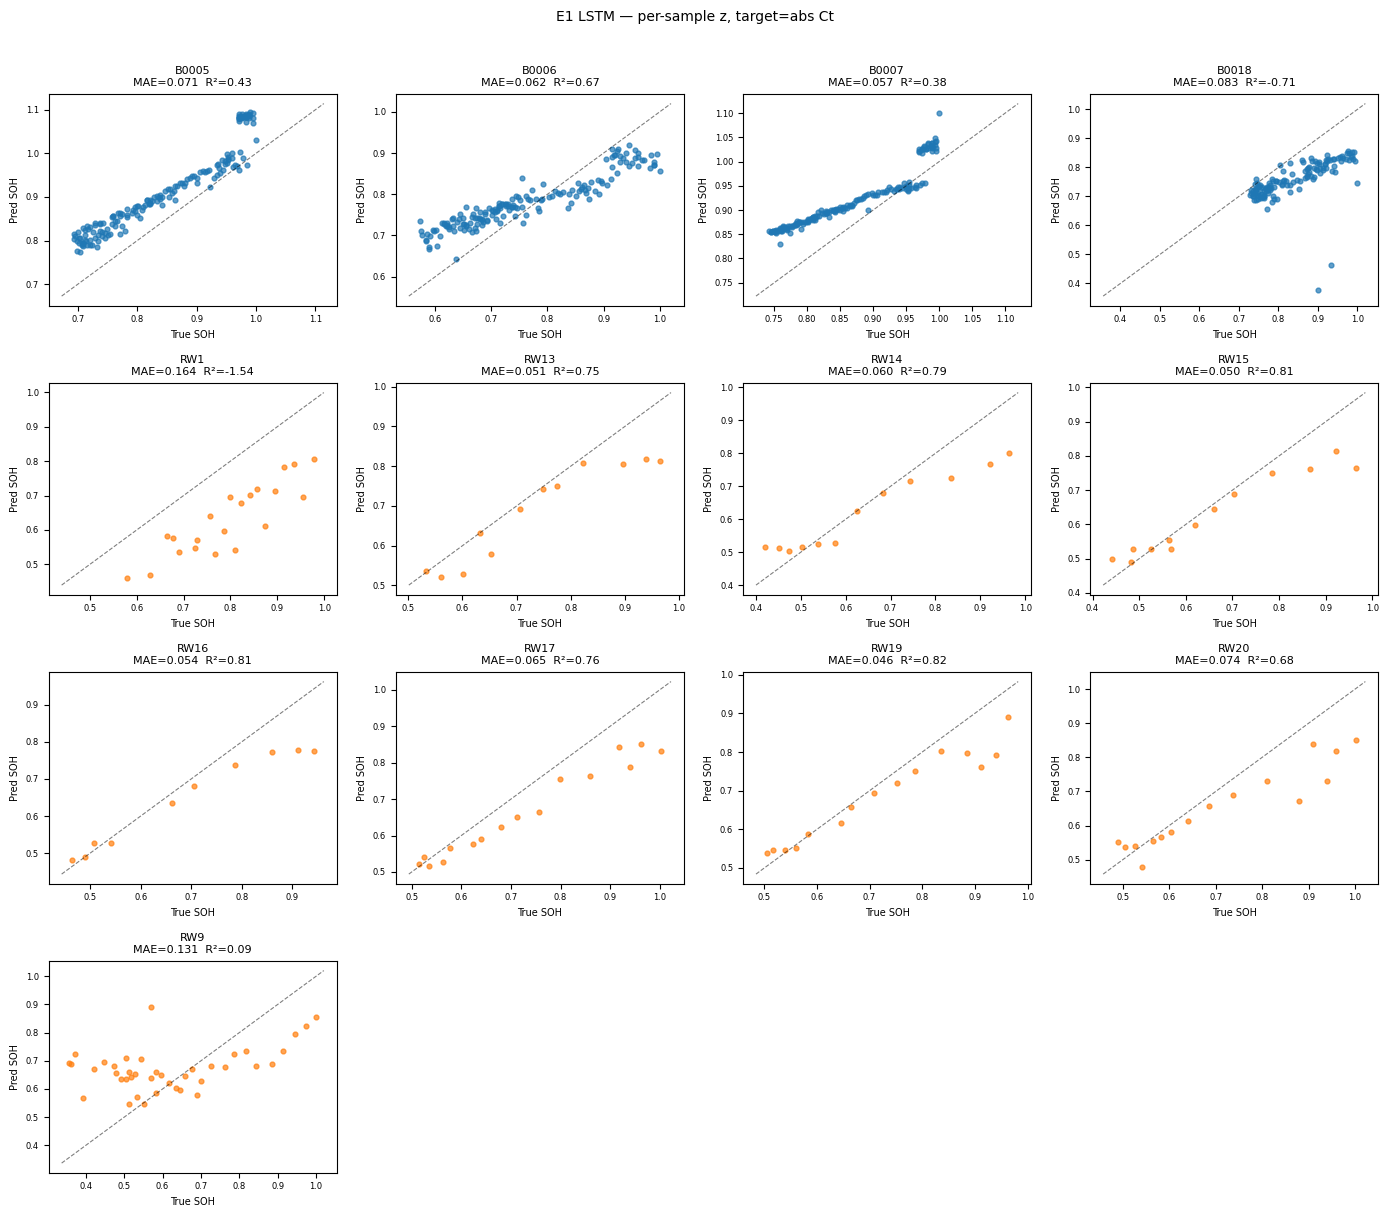

In [24]:
per_fold_plot(
    res_e1_lstm_ps["per_fold"],
    "E1 LSTM — per-sample z, target=abs Ct",
    save_path=RESULTS / "07_e1_lstm_ps_per_fold.png",
)

In [21]:
# E1b — LSTM, global scaling, target=Ct
# Global scaling preserves the absolute Ct signal (inter-sample amplitude).
arch_e1b = lambda: LSTMRegPooled(C, hidden=64, dropout=0.25)
res_e1_lstm_gl = run_lobo_lstm(arch_e1b, cap_ahr, "global", label="LSTM E1 global")
print_summary_line("E1 LSTM global (Ct)", res_e1_lstm_gl)

LOBO LSTM E1 global:   0%|          | 0/13 [00:00<?, ?fold/s]

E1 LSTM global (Ct)         MAE=0.0565±0.0325  R²=0.519±0.552  skill=0.549  mono=0.662


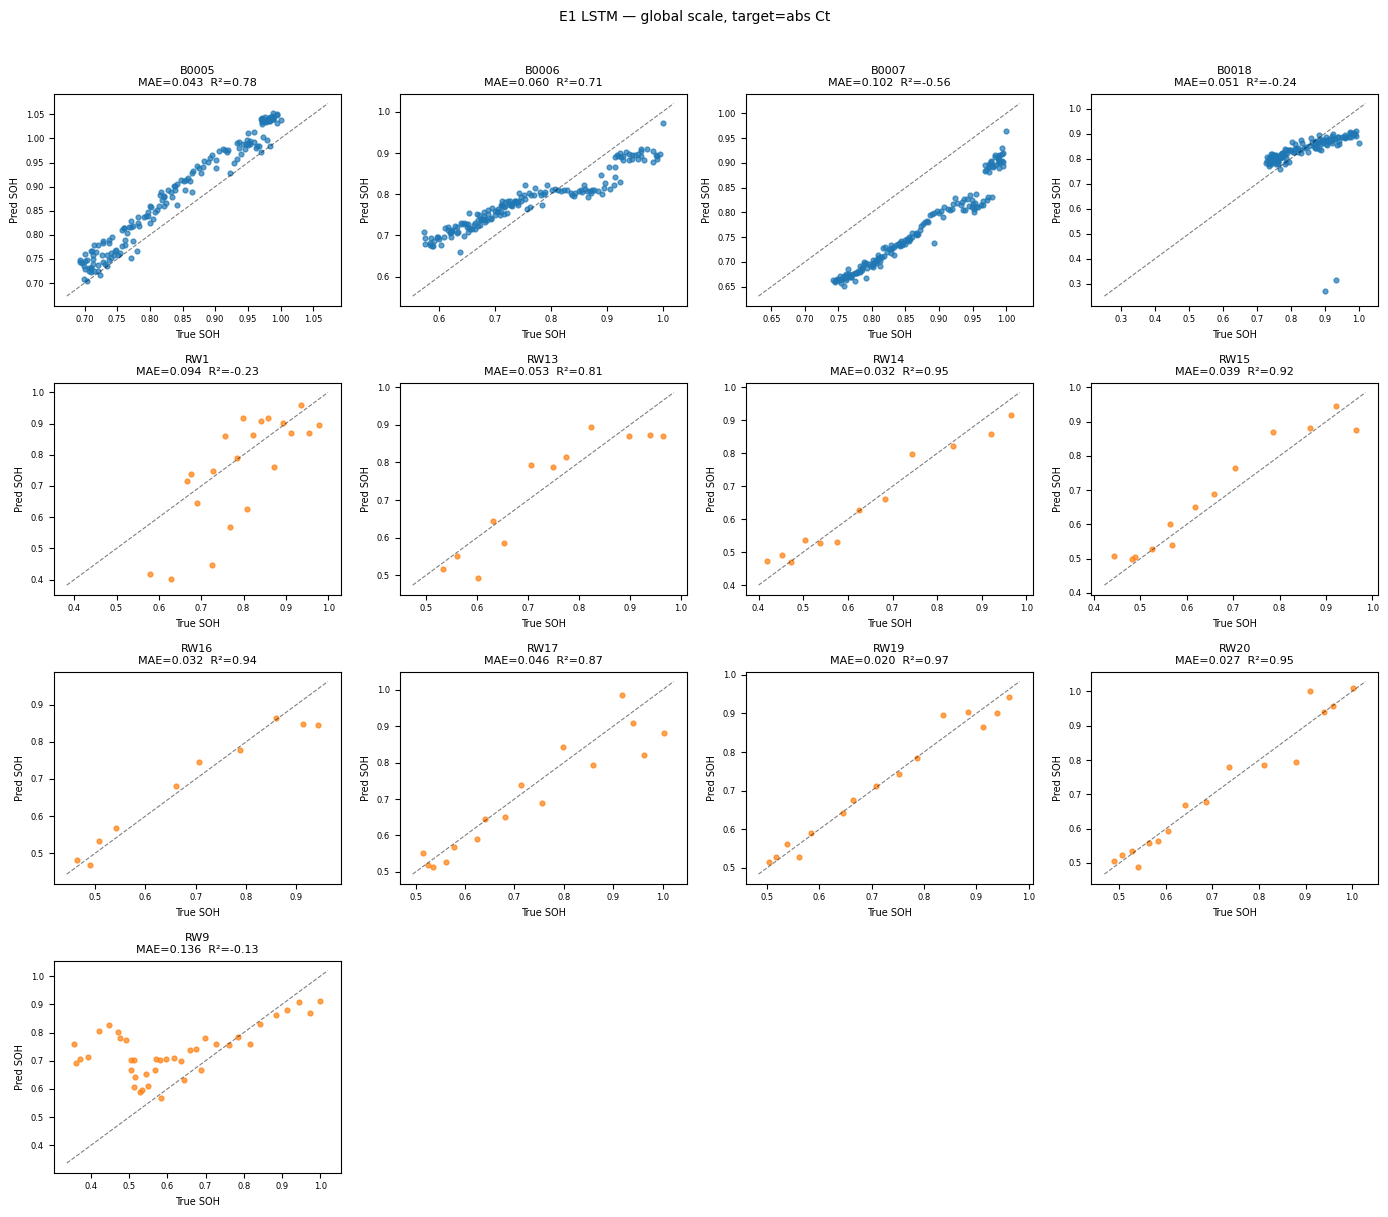

In [25]:
per_fold_plot(
    res_e1_lstm_gl["per_fold"],
    "E1 LSTM — global scale, target=abs Ct",
    save_path=RESULTS / "07_e1_lstm_gl_per_fold.png",
)

Global norm is the winner here - it compliments delta SOH, not surprising.

---
## E2 — Stress Markers

128-pt resampling erases the CV-taper **duration** and `per_sample_scale` erases **amplitude**.
We restore them as explicit scalar features fed through the LSTM's hybrid head:

| Feature | Source | What it captures |
|---------|--------|------------------|
| `cum_ah_lifetime` | discharge (causal, shifted by 1) | Total lifetime stress/age |
| `load_std` | discharge (causal, shifted by 1) | Load variability: ~0 controlled, high RW |
| `V_min`, `V_max` | raw charge curve X | Absolute voltage amplitude |
| `I_mean`, `I_std` | raw charge curve X | Absolute charge current magnitude |

**Update `E2_SCALE` below** after inspecting E1 results (default: best of E1a/E1b for LSTM).

In [26]:
# ← Update after seeing E1 results: pick the better of "per_sample" / "global"
E2_SCALE = "global"

print(f"E2 curve scaling: {E2_SCALE}")
print(f"Stress markers: {STRESS_COLS}  shape: {stress_markers.shape}")

E2 curve scaling: global
Stress markers: ['cum_ah_lifetime', 'load_std', 'V_min', 'V_max', 'I_mean', 'I_std']  shape: (788, 6)


In [27]:
# E2 — RF (charge scalars + stress markers, target=Ct)
rf_e2_feats = np.concatenate([charge_sc, stress_markers], axis=1)
res_e2_rf = run_lobo_rf(rf_e2_feats, cap_ahr, label="RF E2 (Ct+stress)")
print_summary_line("E2 RF (Ct+stress)", res_e2_rf)

LOBO RF E2 (Ct+stress):   0%|          | 0/13 [00:00<?, ?it/s]

E2 RF (Ct+stress)           MAE=0.0534±0.0391  R²=0.647±0.418  skill=0.602  mono=0.718


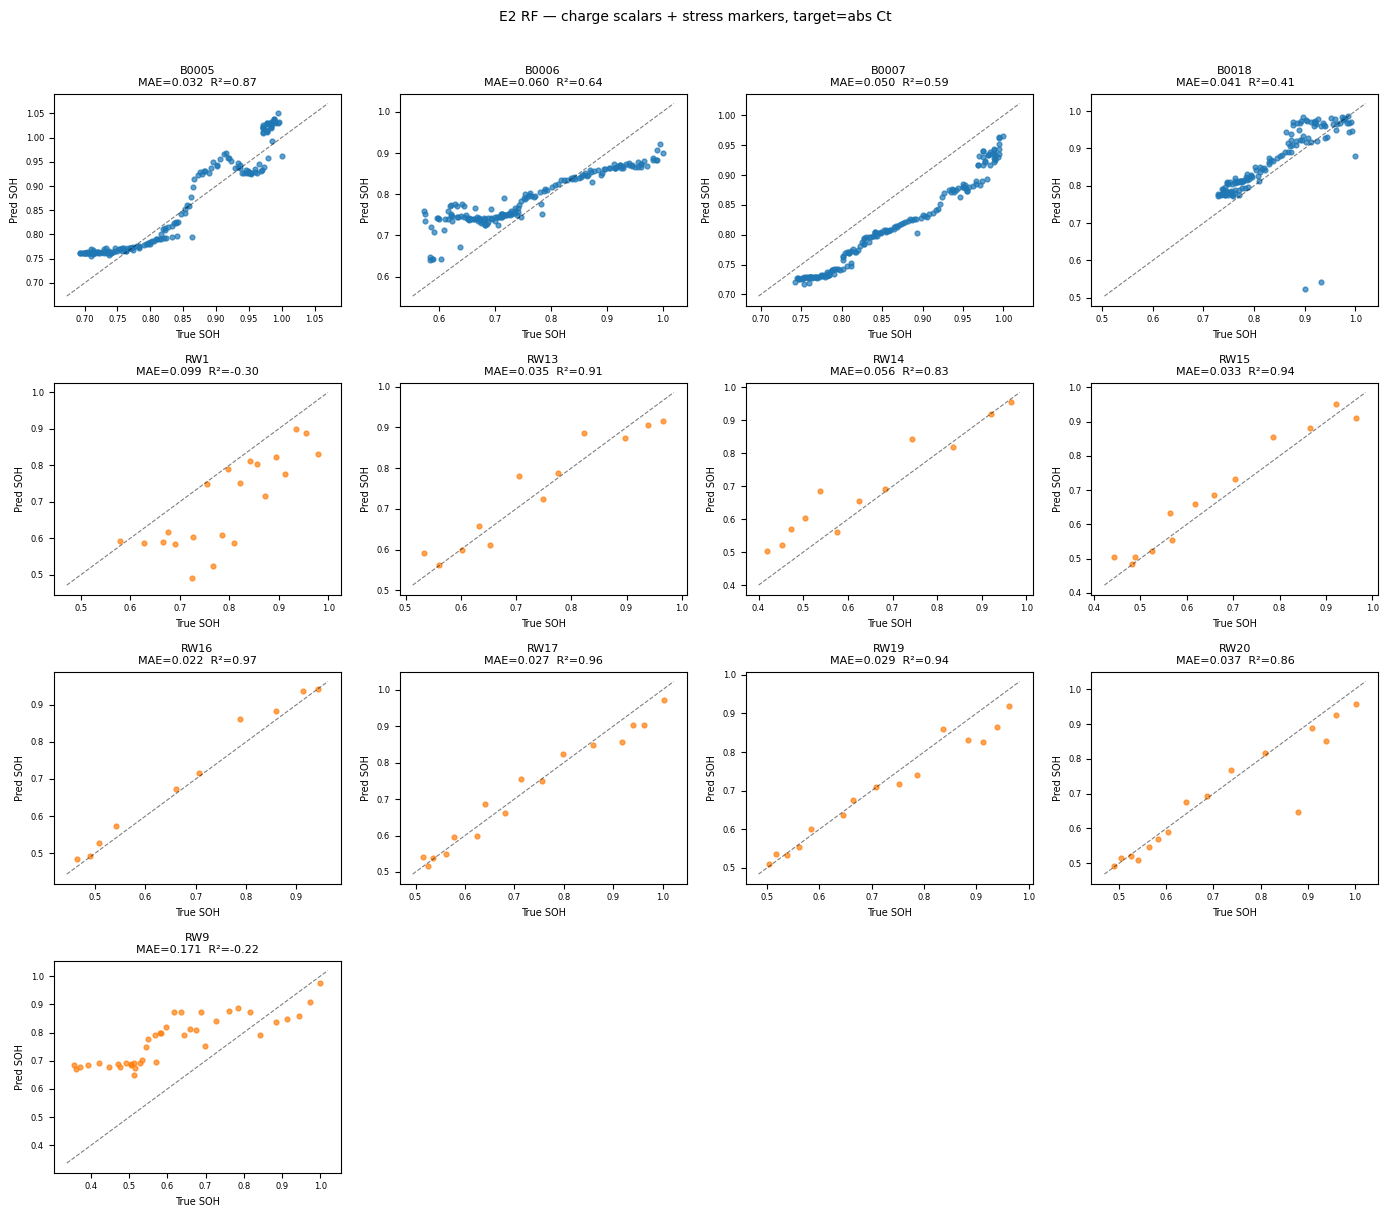

In [28]:
per_fold_plot(
    res_e2_rf["per_fold"],
    "E2 RF — charge scalars + stress markers, target=abs Ct",
    save_path=RESULTS / "07_e2_rf_per_fold.png",
)

-0.01 to MAE mean and std. Curves look much tighter which is good, especially on the controlled set.

RF importance pass:   0%|          | 0/13 [00:00<?, ?it/s]

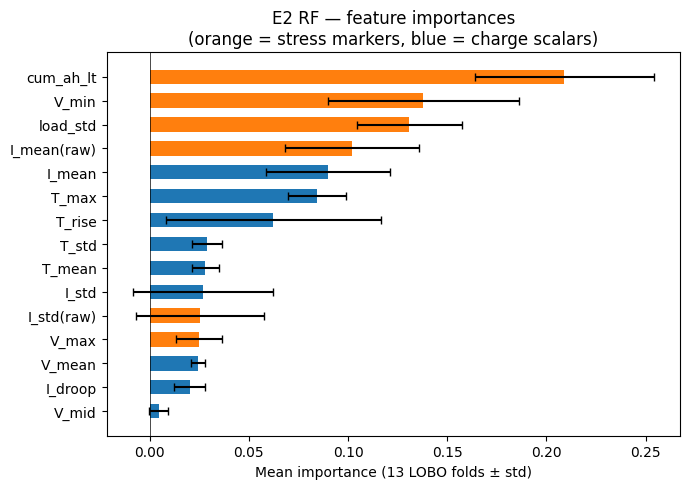

Top 5:
  cum_ah_lt              0.2090 ← stress
  V_min                  0.1380 ← stress
  load_std               0.1309 ← stress
  I_mean(raw)            0.1022 ← stress
  I_mean                 0.0900

Stress marker ranks:
  #1   cum_ah_lt              0.2090
  #2   V_min                  0.1380
  #3   load_std               0.1309
  #4   I_mean(raw)            0.1022
  #11  I_std(raw)             0.0255
  #12  V_max                  0.0250


In [29]:
# ── E2 RF feature importances (LOBO-aggregated) ──────────────────────────────
# Disambiguate names: I_mean/I_std appear in both charge_sc and stress_markers
# (charge_sc is from raw X too, so they're numerically identical — RF splits
# importance across them). Label the stress-marker copies as "(raw)" to tell them apart.
e2_feat_cols = CHARGE_SC_COLS + ["cum_ah_lt", "load_std", "V_min", "V_max", "I_mean(raw)", "I_std(raw)"]
IS_STRESS    = [False]*len(CHARGE_SC_COLS) + [True]*len(STRESS_COLS)

rf_e2_feats  = np.concatenate([charge_sc, stress_markers], axis=1)

fold_imps = []
for held_out in tqdm(all_bids, desc="RF importance pass"):
    is_train = battery_id != held_out
    sc = StandardScaler().fit(rf_e2_feats[is_train])
    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(sc.transform(rf_e2_feats[is_train]), cap_ahr[is_train])
    fold_imps.append(rf.feature_importances_)

imp      = np.array(fold_imps)          # (13, 15)
imp_mean = imp.mean(axis=0)
imp_std  = imp.std(axis=0)

order   = np.argsort(imp_mean)          # ascending, for horizontal bar (bottom=lowest)
labels  = np.array(e2_feat_cols)[order]
stress  = np.array(IS_STRESS)[order]
colors  = ["#ff7f0e" if s else "#1f77b4" for s in stress]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(labels, imp_mean[order], xerr=imp_std[order], color=colors, capsize=3, height=0.6)
ax.set_xlabel("Mean importance (13 LOBO folds ± std)")
ax.set_title("E2 RF — feature importances\n(orange = stress markers, blue = charge scalars)")
ax.axvline(0, color="k", lw=0.5)
plt.tight_layout()
plt.savefig(RESULTS / "07_e2_rf_importances.png", dpi=120, bbox_inches="tight")
plt.show()

# Quick text summary: top-5 and stress-marker ranks
ranked = sorted(zip(imp_mean, e2_feat_cols, IS_STRESS), reverse=True)
print("Top 5:")
for imp_v, name, is_s in ranked[:5]:
    tag = " ← stress" if is_s else ""
    print(f"  {name:<22} {imp_v:.4f}{tag}")
print("\nStress marker ranks:")
for rank, (imp_v, name, is_s) in enumerate(ranked, 1):
    if is_s:
        print(f"  #{rank:<3} {name:<22} {imp_v:.4f}")

In [ ]:
# E2 — LSTM (curve + stress markers as hybrid scalars, target=Ct)
n_stress  = stress_markers.shape[1]   # 6
arch_e2   = lambda: LSTMRegPooled(C, hidden=64, dropout=0.25, n_scalars=n_stress)
res_e2_lstm = run_lobo_lstm(
    arch_e2, cap_ahr, E2_SCALE, scalar_arr=stress_markers,
    label=f"LSTM E2 ({E2_SCALE}+stress)"
)
print_summary_line(f"E2 LSTM {E2_SCALE} (Ct+stress)", res_e2_lstm)

LOBO LSTM E2 (global+stress):   0%|          | 0/13 [00:00<?, ?fold/s]

In [ ]:
per_fold_plot(
    res_e2_lstm["per_fold"],
    f"E2 LSTM — {E2_SCALE} + stress markers, target=abs Ct",
    save_path=RESULTS / f"07_e2_lstm_{E2_SCALE}_per_fold.png",
)

---
## Summary

All metrics are in **SOH space** (comparable to nb06).
The two hard folds (RW1, RW9) are called out separately — they drive the aggregate R² variance.

In [ ]:
arms = {
    "B0 RF":              res_b0_rf,
    "B0 LSTM (ps)": res_b0_lstm,
    "E1 RF (Ct)":         res_e1_rf,
    "E1 LSTM ps (Ct)":    res_e1_lstm_ps,
    "E1 LSTM gl (Ct)":    res_e1_lstm_gl,
    "E2 RF (Ct+str)":     res_e2_rf,
    f"E2 LSTM {E2_SCALE} (Ct+str)": res_e2_lstm,
}

def fmt(v, s=None, d=4):
    if v is None or (isinstance(v, float) and np.isnan(v)): return "—"
    base = f"{v:.{d}f}"
    return f"{base} ± {s:.{d}f}" if s is not None else base

print(f"{'Arm':<30}  {'MAE (±std)':>18}  {'R² (±std)':>16}  {'Skill':>7}  {'Mono':>7}")
print("-" * 86)
for arm, res in arms.items():
    print(
        f"{arm:<30}  "
        f"{fmt(res.get('mae'), res.get('mae_std')):>18}  "
        f"{fmt(res.get('r2'),  res.get('r2_std'),  d=3):>16}  "
        f"{fmt(res.get('skill')):>7}  "
        f"{fmt(res.get('monotonicity')):>7}"
    )

print()
print(f"{'Arm':<30}  {'RW1 MAE':>9}  {'RW1 R²':>9}  {'RW9 MAE':>9}  {'RW9 R²':>9}")
print("-" * 70)
for arm, res in arms.items():
    fd  = {f["battery"]: f for f in res["per_fold"]}
    rw1 = fd.get("RW1", {}); rw9 = fd.get("RW9", {})
    print(
        f"{arm:<30}  "
        f"{rw1.get('mae', float('nan')):>9.4f}  "
        f"{rw1.get('r2',  float('nan')):>9.3f}  "
        f"{rw9.get('mae', float('nan')):>9.4f}  "
        f"{rw9.get('r2',  float('nan')):>9.3f}"
    )